Data shape: (200352, 275)
Explained variance ratio (PCA 2D): [0.31465965 0.1405366 ]


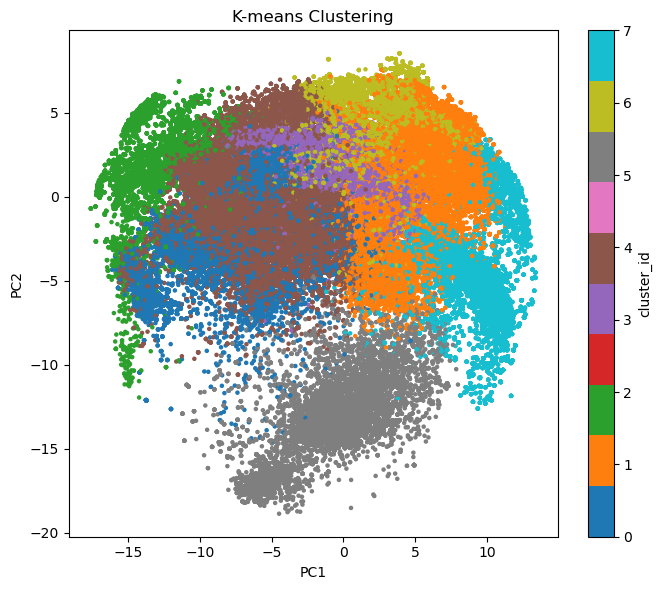

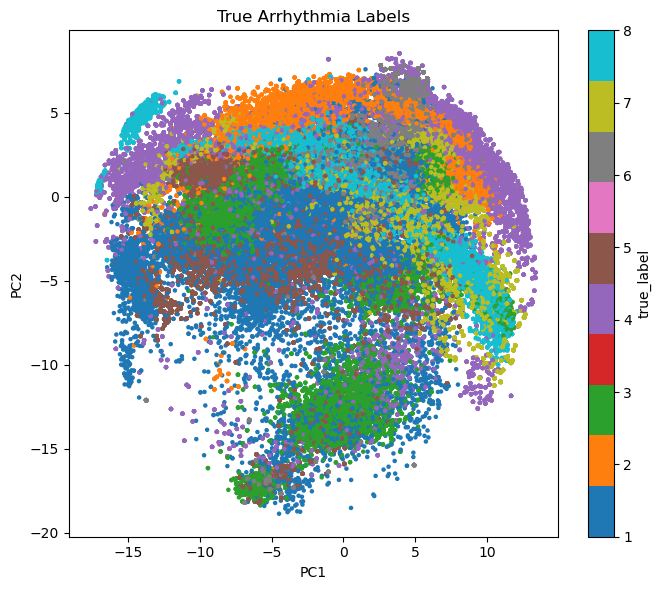

Classification accuracy using cluster labels: 0.14388675930362563


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("train_patients.csv", header=None)
X = df.iloc[:, :275].values
y = df.iloc[:, 275].values
print("Data shape:", X.shape)


# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Explained variance ratio (PCA 2D):", pca.explained_variance_ratio_)


kmeans = KMeans(n_clusters=8, random_state=42)
cluster_labels = kmeans.fit_predict(X)


plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap="tab10", s=5)
plt.title("K-means Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster_id")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", s=5)
plt.title("True Arrhythmia Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="true_label")
plt.tight_layout()
plt.show()


# Classification using cluster features
X_cluster = cluster_labels.reshape(-1, 1)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cluster, y, test_size=0.25, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=500)
clf.fit(X_tr, y_tr)

pred = clf.predict(X_te)

print("Classification accuracy using cluster labels:",
      accuracy_score(y_te, pred))


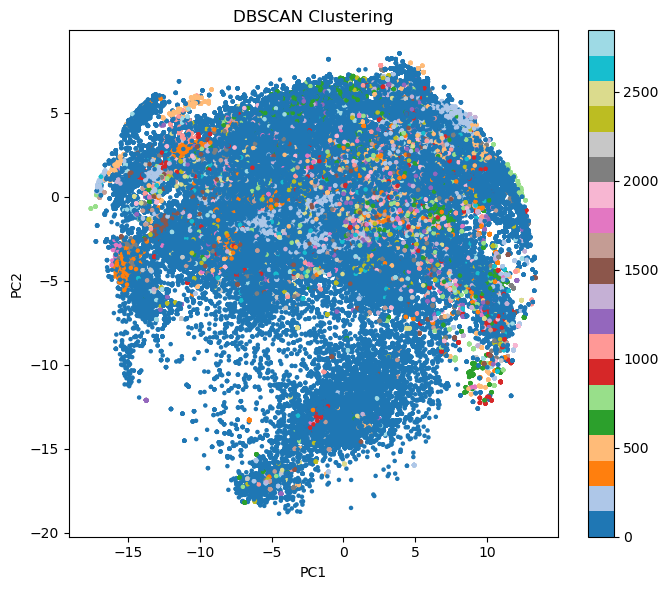

Number of clusters found: 2847
Noise points: 74993


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=3.0, min_samples=10)
cluster_db = db.fit_predict(X_scaled)


plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_db, cmap="tab20", s=5)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.tight_layout()
plt.show()

print("Number of clusters found:", len(set(cluster_db)))
print("Noise points:", sum(cluster_db == -1))


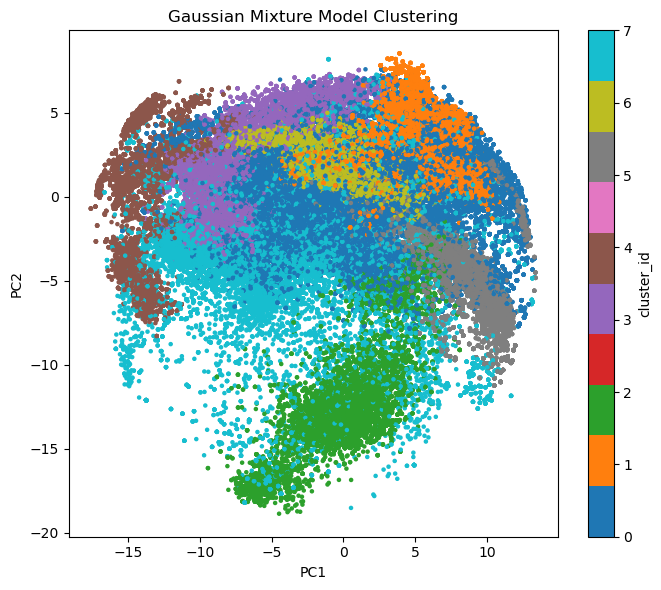

In [3]:
from sklearn.mixture import GaussianMixture

pca_gmm = PCA(n_components=30)
X_gmm = pca_gmm.fit_transform(X)

gmm = GaussianMixture(
    n_components=8,
    covariance_type="full",
    random_state=42
)
gmm.fit(X_gmm)

cluster_gmm = gmm.predict(X_gmm)


plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_gmm,
    cmap="tab10",
    s=5
)
plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster_id")
plt.tight_layout()
plt.show()


In [4]:
# GMM soft cluster features
X_gmm_feat = gmm.predict_proba(X_gmm)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_gmm_feat,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

clf = LogisticRegression(max_iter=500)
clf.fit(X_tr, y_tr)

pred = clf.predict(X_te)
print("Classification accuracy using GMM soft cluster features:",
      accuracy_score(y_te, pred))

Classification accuracy using GMM soft cluster features: 0.4232750359367513


Subset shape: (10000, 275)


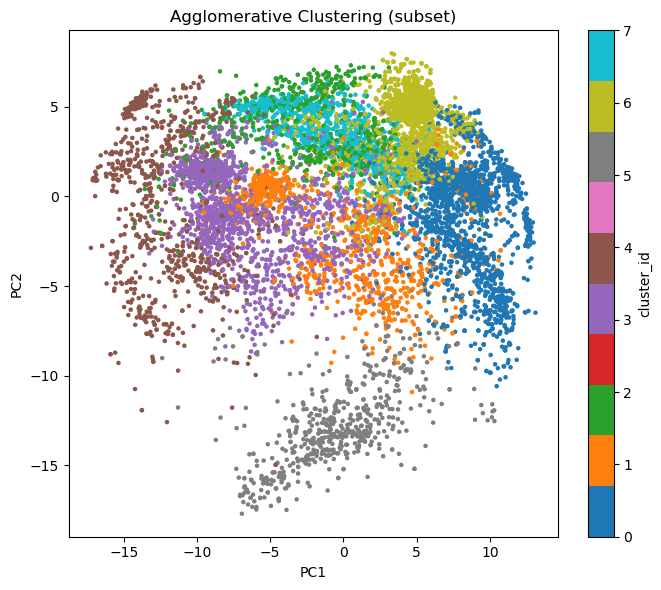

In [5]:
from sklearn.cluster import AgglomerativeClustering

SUBSET_SIZE = 10000


# Subset from original feature space
X_sub, _, y_sub, _ = train_test_split(
    X, y,
    train_size=SUBSET_SIZE,
    stratify=y,
    random_state=42
)

print("Subset shape:", X_sub.shape)


agg = AgglomerativeClustering(
    n_clusters=8,
    linkage="ward"
)
cluster_agg = agg.fit_predict(X_sub)


pca_sub = PCA(n_components=2)
X_sub_pca = pca_sub.fit_transform(X_sub)

plt.figure(figsize=(7, 6))
plt.scatter(
    X_sub_pca[:, 0],
    X_sub_pca[:, 1],
    c=cluster_agg,
    cmap="tab10",
    s=5
)
plt.title("Agglomerative Clustering (subset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster_id")
plt.tight_layout()
plt.show()


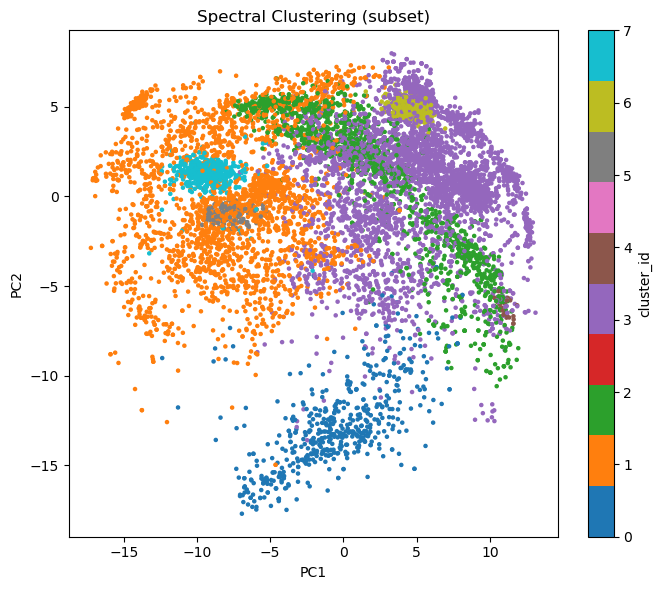

In [6]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=8,
    affinity="nearest_neighbors",
    n_neighbors=15,
    assign_labels="kmeans",
    random_state=42,
    n_init=10
)

cluster_spec = spectral.fit_predict(X_sub)


plt.figure(figsize=(7, 6))
plt.scatter(
    X_sub_pca[:, 0],
    X_sub_pca[:, 1],
    c=cluster_spec,
    cmap="tab10",
    s=5
)
plt.title("Spectral Clustering (subset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster_id")
plt.tight_layout()
plt.show()
